In [2]:
import sys
sys.path.append("../")
from data_prep import load_laps

test = load_laps(year=2023, session_name='Sprint')
print(len(test))

2170


In [3]:
import sys
sys.path.append("../")
from data_prep import load_laps, load_session_results, check_missing_sessions, load_pit_stops, dbset

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

- [ ] Why do some drivers/teams consistently qualify better than others is it car pace or driver skill? (compare teammates' qualifying deltas across a season  same car, isolates driver effect)
- [ ] How strongly does grid position actually predict finishing position? (simple linear regression, R², correlation coefficient)
- [ ] Does grid position's predictive power vary by circuit type (street vs. permanent, high-overtaking vs. processional)? (subgroup regression / interaction term)

In [9]:
import pandas as pd
from scipy import stats
import sqlite3

conn = sqlite3.connect("../DATA INGESTION/f1.db")

query = """
SELECT gs.year, gm.meeting_name, g.driver_number,
       g."position" AS grid_position,
       sr."position" AS final_position
FROM silver_starting_grid g
JOIN silver_sessions gs ON g.session_key = gs.session_key
JOIN silver_meetings gm ON gs.meeting_key = gm.meeting_key
JOIN silver_sessions rs ON rs.meeting_key = gs.meeting_key AND rs.session_name = 'Race'
JOIN silver_session_result sr ON sr.session_key = rs.session_key AND sr.driver_number = g.driver_number
WHERE gs.session_name = 'Qualifying'
  AND sr.dns = 0 AND sr.dnf = 0 AND sr.dsq = 0
  AND sr."position" IS NOT NULL
"""

df = pd.read_sql(query, conn)
df

,year,meeting_name,driver_number,grid_position,final_position
0,2023,Saudi Arabian Grand Prix,11,1,1
1,2023,Saudi Arabian Grand Prix,1,15,2
2,2023,Saudi Arabian Grand Prix,14,2,3
3,2023,Saudi Arabian Grand Prix,63,3,4
4,2023,Saudi Arabian Grand Prix,44,7,5
...,...,...,...,...,...
1167,2026,Austrian Grand Prix,87,13,14
1168,2026,Austrian Grand Prix,43,16,15
1169,2026,Austrian Grand Prix,31,15,16
1170,2026,Austrian Grand Prix,23,18,17


<Axes: xlabel='grid_position', ylabel='final_position'>

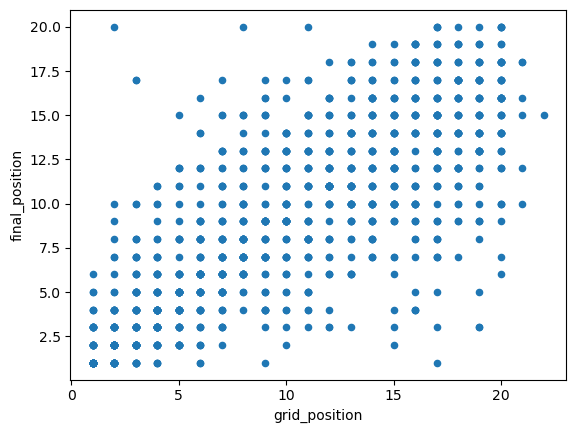

In [7]:
df.plot.scatter(x='grid_position', y='final_position')

slope: 0.682
intercept: 2.270
r (correlation): 0.768
R^2: 0.590
p-value: 7.63e-229
stderr: 0.017


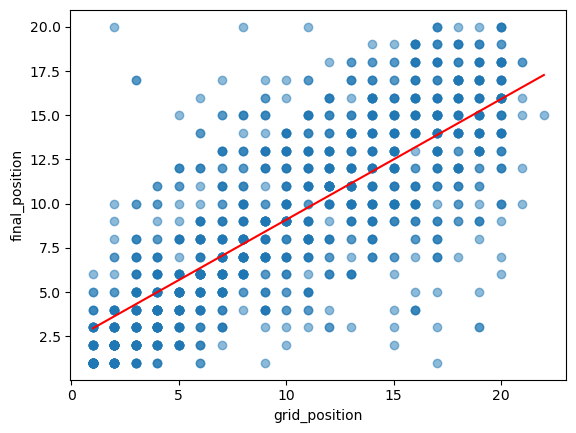

In [13]:
import matplotlib.pyplot as plt
from scipy import stats

result = stats.linregress(df['grid_position'], df['final_position'])

print(f"slope: {result.slope:.3f}")
print(f"intercept: {result.intercept:.3f}")
print(f"r (correlation): {result.rvalue:.3f}")
print(f"R^2: {result.rvalue**2:.3f}")
print(f"p-value: {result.pvalue:.2e}")
print(f"stderr: {result.stderr:.3f}")


fig, ax = plt.subplots()
ax.scatter(df['grid_position'], df['final_position'], alpha=0.5)
x_line = df['grid_position'].sort_values()
ax.plot(x_line, result.slope * x_line + result.intercept, color='red')
ax.set_xlabel('grid_position')
ax.set_ylabel('final_position')
plt.show()

- [X] How strongly does grid position actually predict finishing position? (simple linear regression, R², correlation coefficient)

Grid position explains 59% of the variation we see in finishing positions across all drivers and races. The remaining 41% is due to other factors like race incidents, strategy, pace, weather, etc.


---

Scope: 2023, Race sessions only, DNS/DNF/DSQ excluded , isolates the "clean race" effect.

slope: 0.682     -> On average, each grid place further back costs ~0.68 finishing 
                    places. NOT a percentage, not a measure of prediction quality ,
                    it's a rate (units: finish-positions per grid-position).

intercept: 2.270  -> Predicted finish position at grid_position = 0. Not physically
                    meaningful here (grid starts at 1) , just an artifact of the line.

r: 0.768          -> Correlation strength/direction. Matches df.corr() exactly,
                    that's the sanity check that linregress and pandas agree.

R^2: 0.590        -> THE "how good is this model" number. 59% of the variance in
                    finish position is explained by grid position alone. The other
                    41% is strategy, incidents, pace, luck, weather, etc. This is
                    the number to quote when someone asks "how strong is the effect."

p-value: 7.63e-229 -> Answers a DIFFERENT question than R²: "is the slope definitely
                    not zero?" Tiny p-value = yes, essentially certain. It does NOT
                    mean the model is accurate or the effect is large ,with a big
                    enough sample, even a weak real effect gets a tiny p-value.
                    TRAP: don't read a small p-value as "strong effect." That's R²'s job.

stderr: 0.017     -> Standard error of the SLOPE estimate (analytic, not bootstrapped 
                    , linregress computes this directly from the residuals/sample size).
                    Small stderr = the slope (0.682) is precisely pinned down; if I
                    reran this on a different sample of races, I'd expect a similar
                    slope. This is about confidence in the SLOPE VALUE, not about how
                    well the model predicts individual outcomes. TRAP: precision of an
                    estimate =/= strength of a relationship — those are independent.

TAKEAWAY: Grid position has a real, precisely-measured, statistically certain effect
on finishing position (p-value, stderr) , but that effect is moderate in strength
(R²=0.59), leaving considerable room for race-day factors to still change the outcome.

RULE OF THUMB for every regression from here on:
- R² -> strength of the relationship (how good is prediction)
- p-value / stderr -> confidence that the slope is real and well-estimated
  (NOT how good the model is)
These two axes are independent. A model can be "certainly real, but weak"
(common with large samples) or "uncertain but potentially strong" (common
with small samples) — never assume one implies the other.

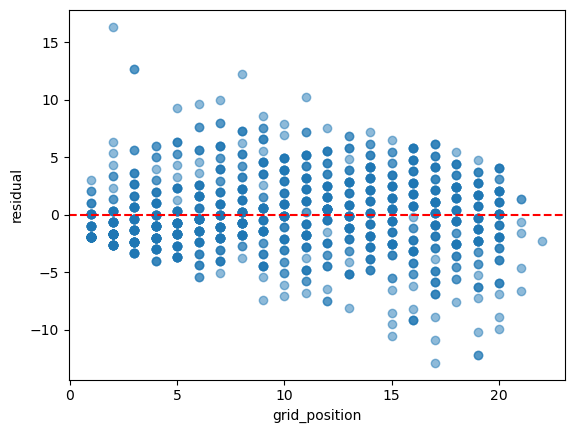

In [14]:
fig, ax = plt.subplots()
ax.scatter(df['grid_position'], df['residual'], alpha=0.5)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('grid_position')
ax.set_ylabel('residual')
plt.show()

Residual spread is NOT uniform across grid_position (heteroscedasticity confirmed).
Narrowest at grid extremes (P1-3, P18+), widest in the midfield (P5-17).
Implication: R²=0.59 is an average fit quality , front-row starts are more
predictable than midfield starts. A single linear model slightly understates
predictability at the front and overstates it in the middle.

<Axes: >

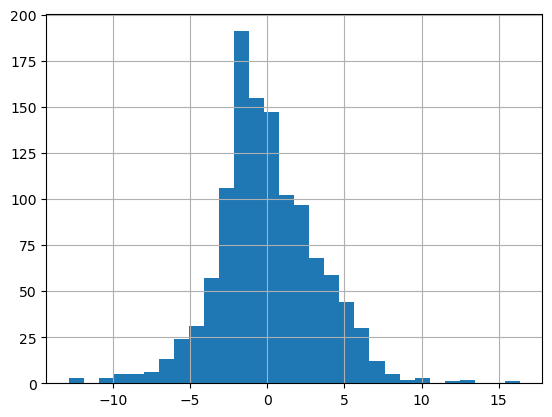

In [15]:
df['residual'].hist(bins=30)